In [1]:
import pandas as pd

import medagent as ma

DEMO = True

ma.reload()

In [3]:
ma.config.debug()

C:\Users\daiyi\Documents\Github\MedAgent\.venv\Scripts\python.exe


In [4]:
admissions = ma.load_data("admissions", demo=DEMO)
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [5]:
admissions.info()
print(f"Number of rows: {admissions.size}")

<class 'pandas.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   subject_id            275 non-null    int64
 1   hadm_id               275 non-null    int64
 2   admittime             275 non-null    str  
 3   dischtime             275 non-null    str  
 4   deathtime             15 non-null     str  
 5   admission_type        275 non-null    str  
 6   admit_provider_id     275 non-null    str  
 7   admission_location    275 non-null    str  
 8   discharge_location    233 non-null    str  
 9   insurance             275 non-null    str  
 10  language              275 non-null    str  
 11  marital_status        263 non-null    str  
 12  race                  275 non-null    str  
 13  edregtime             182 non-null    str  
 14  edouttime             182 non-null    str  
 15  hospital_expire_flag  275 non-null    int64
dtypes: int64(3), str(13

**Goal**

* Predict LOS (length of stay in days)
* Readmission risk (Bern: Will they come back in 30 days? Probability?)

In [6]:
admissions = ma.load_data(
    "hosp/admissions", demo=DEMO
)  # in / out time for LOS calculation
patients = ma.load_data("hosp/patients", demo=DEMO)  # in / out time for LOS calculation
icustays = ma.load_data("icu/icustays", demo=DEMO)  # Predict readmission risk


print(f"Number of rows admissions: {admissions.size}")
print(f"Number of rows patients: {patients.size}")
print(f"Number of rows icustays: {icustays.size}")


print(admissions.columns.tolist())
print(patients.columns.tolist())
print(icustays.columns.tolist())

# All three keys join on subject id

Number of rows admissions: 4400
Number of rows patients: 600
Number of rows icustays: 1120
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']
['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los']


In [7]:
df = admissions.merge(
    patients, on="subject_id", how="inner"
)  # inner keeps information and rows for LOS prediction and readmission risk prediction
df = df.merge(icustays, on=["subject_id", "hadm_id"], how="inner")

In [8]:
df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,anchor_age,anchor_year,anchor_year_group,dod,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,...,47,2196,2014 - 2016,NaN,34100191,Coronary Care Unit (CCU),Medical Intensive Care Unit (MICU),2196-02-24 17:07:00,2196-02-29 15:58:02,4.952106
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,...,58,2153,2011 - 2013,NaN,35258379,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2153-09-19 09:54:49,2153-09-21 16:39:06,2.280752
2,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,...,52,2111,2014 - 2016,2111-11-15,34617352,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2111-11-14 00:19:12,2111-11-15 18:21:10,1.751366
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,...,52,2111,2014 - 2016,2111-11-15,32895909,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2111-11-13 23:40:00,2111-11-14 00:14:10,0.023727
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,...,82,2113,2014 - 2016,NaN,35544374,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2113-08-04 18:47:42,2113-08-05 23:45:02,1.206481


In [9]:
print(f"Number of rows in merged dataset: {df.shape[0]}")

Number of rows in merged dataset: 140


In [10]:
print(f"admissions: {admissions.shape}")
print(f"patients:   {patients.shape}")
print(f"icustays:   {icustays.shape}")
print(f"merged df:  {df.shape}")

admissions: (275, 16)
patients:   (100, 6)
icustays:   (140, 8)
merged df:  (140, 27)


**Explore distribution of LOS and readmission sample space**

In [11]:
df.head(1)

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,anchor_age,anchor_year,anchor_year_group,dod,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,...,47,2196,2014 - 2016,NaN,34100191,Coronary Care Unit (CCU),Medical Intensive Care Unit (MICU),2196-02-24 17:07:00,2196-02-29 15:58:02,4.952106


In [12]:
for col in df.columns:
    print(f"{col}: {df[col].dtype} | sample: {df[col].dropna().iloc[0]}")

subject_id: int64 | sample: 10004235
hadm_id: int64 | sample: 24181354
admittime: str | sample: 2196-02-24 14:38:00
dischtime: str | sample: 2196-03-04 14:02:00
deathtime: str | sample: 2111-11-15 17:20:00
admission_type: str | sample: URGENT
admit_provider_id: str | sample: P03YMR
admission_location: str | sample: TRANSFER FROM HOSPITAL
discharge_location: str | sample: SKILLED NURSING FACILITY
insurance: str | sample: Medicaid
language: str | sample: ENGLISH
marital_status: str | sample: SINGLE
race: str | sample: BLACK/CAPE VERDEAN
edregtime: str | sample: 2196-02-24 12:15:00
edouttime: str | sample: 2196-02-24 17:07:00
hospital_expire_flag: int64 | sample: 0
gender: str | sample: M
anchor_age: int64 | sample: 47
anchor_year: int64 | sample: 2196
anchor_year_group: str | sample: 2014 - 2016
dod: str | sample: 2111-11-15
stay_id: int64 | sample: 34100191
first_careunit: str | sample: Coronary Care Unit (CCU)
last_careunit: str | sample: Medical Intensive Care Unit (MICU)
intime: str 

## Dataset overview

The merged dataframe combines three MIMIC-IV demo tables — `admissions`, `patients`, and `icustays` — 
joined on `subject_id` and `hadm_id`. It contains **100 demo patients** with **27 columns** spanning 
hospital admission records and ICU stay details.

**Key columns by category:**

- **IDs:** `subject_id` (patient), `hadm_id` (hospital admission), `stay_id` (ICU stay)
- **Admission timing:** `admittime`, `dischtime`, `edregtime`, `edouttime`
- **ICU timing:** `intime`, `outtime`, `los` (length of stay in days — our regression target)
- **Patient demographics:** `anchor_age`, `gender`, `race`, `language`, `marital_status`, `insurance`
- **Clinical:** `admission_type`, `first_careunit`, `last_careunit`, `hospital_expire_flag`
- **Mortality:** `deathtime`, `dod` (date of death), `hospital_expire_flag`

**Target variables:**
- `los` — continuous, length of ICU stay in days (for regression)
- Readmission — to be engineered from `admittime`/`dischtime` across multiple admissions

**Notes:**
- Dates are currently stored as strings — will need `pd.to_datetime()` conversion
- `anchor_year` is a shifted year for de-identification; actual calendar year is not meaningful
- `dod` and `deathtime` are present but sparse (only patients who died)

In [13]:
date_cols = [
    "admittime",
    "dischtime",
    "edregtime",
    "edouttime",
    "intime",
    "outtime",
    "deathtime",
    "dod",
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df.shape)

(140, 27)


Matplotlib is building the font cache; this may take a moment.


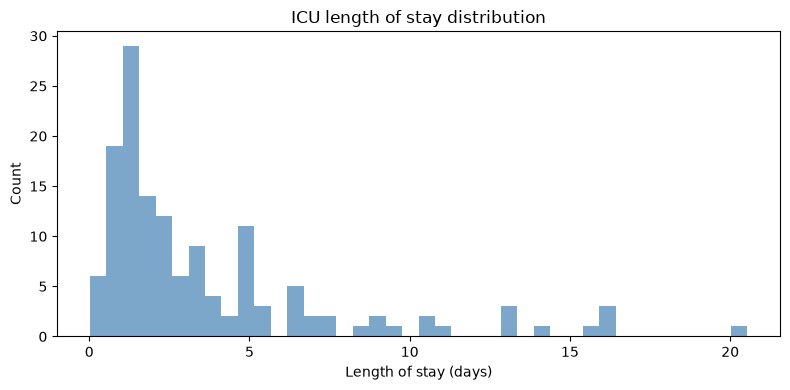

count    140.000000
mean       3.679379
std        3.896354
min        0.023727
25%        1.170663
50%        2.155093
75%        4.907749
max       20.528681
Name: los, dtype: float64


In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["los"], bins=40, color="steelblue", alpha=0.7)
ax.set_xlabel("Length of stay (days)")
ax.set_ylabel("Count")
ax.set_title("ICU length of stay distribution")
plt.tight_layout()
plt.show()

print(df["los"].describe())

LOS looks like an exponential distribution with 

* count: 140
* mean: 3.68
* std: 3.90